# Employee Salary Visualization

This notebook loads employee data from the Neon PostgreSQL database and compares average salary by position and employee start year.

## Load Employee Data

The complete `employees` table is queried with `psycopg2` and loaded into a Pandas DataFrame.

In [2]:
import os
from pathlib import Path

import pandas as pd
import psycopg2
from dotenv import load_dotenv

BASE_DIR = Path.cwd()
load_dotenv(BASE_DIR / '.env')
DATABASE_URL = os.getenv('DATABASE_URL')

with psycopg2.connect(DATABASE_URL) as connection:
    with connection.cursor() as cursor:
        cursor.execute('SELECT * FROM employees')
        rows = cursor.fetchall()
        columns = [column[0] for column in cursor.description]

df = pd.DataFrame(rows, columns=columns)
df['start_date'] = pd.to_datetime(df['start_date'])
df['start_year'] = df['start_date'].dt.year
df.head()

,employee_id,name,start_date,salary,department_id,start_year
0,60,Elizabeth Peterson,2019-01-15,169868,10,2019
1,68,Amanda Weaver,2019-12-11,135953,7,2019
2,76,Tina Tanner,2019-12-07,109270,10,2019
3,77,Brian Perry,2015-12-29,159882,7,2015
4,80,Craig Maldonado,2021-07-26,61523,7,2021


## Join Department Information

The Neon `departments` table uses `department_id` as its primary key. Each employee receives a random department ID, stored as a foreign key in `employees`. The redundant `position` column is removed from `employees`, and department details are retrieved through the join.

In [3]:
department_rows = [
    (1, 'Finance', 'New York', 850000),
    (2, 'Human Resources', 'Chicago', 700000),
    (3, 'Marketing', 'Austin', 950000),
    (4, 'Sales', 'Boston', 1100000),
    (5, 'Finance', 'New York', 850000),
    (6, 'Operations', 'Dallas', 1250000),
    (7, 'Creative Services', 'Austin', 600000),
    (8, 'Customer Experience', 'Denver', 900000),
    (9, 'Operations', 'Dallas', 1000000),
    (10, 'Administration', 'Chicago', 500000),
]

with psycopg2.connect(DATABASE_URL) as connection:
    with connection.cursor() as cursor:
        cursor.execute('ALTER TABLE employees ADD COLUMN IF NOT EXISTS department_id INTEGER')
        cursor.execute(
            """
            CREATE TABLE IF NOT EXISTS departments (
                department_id INTEGER PRIMARY KEY,
                department TEXT NOT NULL,
                location TEXT NOT NULL,
                annual_budget INTEGER NOT NULL CHECK (annual_budget > 0)
            )
            """
        )
        cursor.executemany(
            """
            INSERT INTO departments (department_id, department, location, annual_budget)
            VALUES (%s, %s, %s, %s)
            ON CONFLICT (department_id) DO UPDATE SET
                department = EXCLUDED.department,
                location = EXCLUDED.location,
                annual_budget = EXCLUDED.annual_budget
            """,
            department_rows,
        )
        cursor.execute(
            """
            UPDATE employees
            SET department_id = FLOOR(random() * 10)::integer + 1
            """
        )
        cursor.execute(
            """
            ALTER TABLE employees
            DROP CONSTRAINT IF EXISTS employees_department_id_fkey
            """
        )
        cursor.execute(
            """
            ALTER TABLE employees
            ADD CONSTRAINT employees_department_id_fkey
            FOREIGN KEY (department_id) REFERENCES departments(department_id)
            """
        )
        cursor.execute('ALTER TABLE employees DROP COLUMN IF EXISTS position')
        cursor.execute(
            """
            SELECT
                e.employee_id,
                e.name,
                e.start_date,
                e.salary,
                EXTRACT(YEAR FROM e.start_date)::integer AS start_year,
                e.department_id,
                d.department,
                d.location,
                d.annual_budget
            FROM employees AS e
            INNER JOIN departments AS d
                ON e.department_id = d.department_id
            """
        )
        joined_rows = cursor.fetchall()
        joined_columns = [column[0] for column in cursor.description]

employee_department_df = pd.DataFrame(joined_rows, columns=joined_columns)
employee_department_df.head()

,employee_id,name,start_date,salary,start_year,department_id,department,location,annual_budget
0,60,Elizabeth Peterson,2019-01-15,169868,2019,1,Finance,New York,850000
1,68,Amanda Weaver,2019-12-11,135953,2019,10,Administration,Chicago,500000
2,76,Tina Tanner,2019-12-07,109270,2019,2,Human Resources,Chicago,700000
3,77,Brian Perry,2015-12-29,159882,2015,5,Finance,New York,850000
4,80,Craig Maldonado,2021-07-26,61523,2021,2,Human Resources,Chicago,700000


## Average Salary by Position and Start Year

The grouped bar chart uses one bar for each start year within every position.

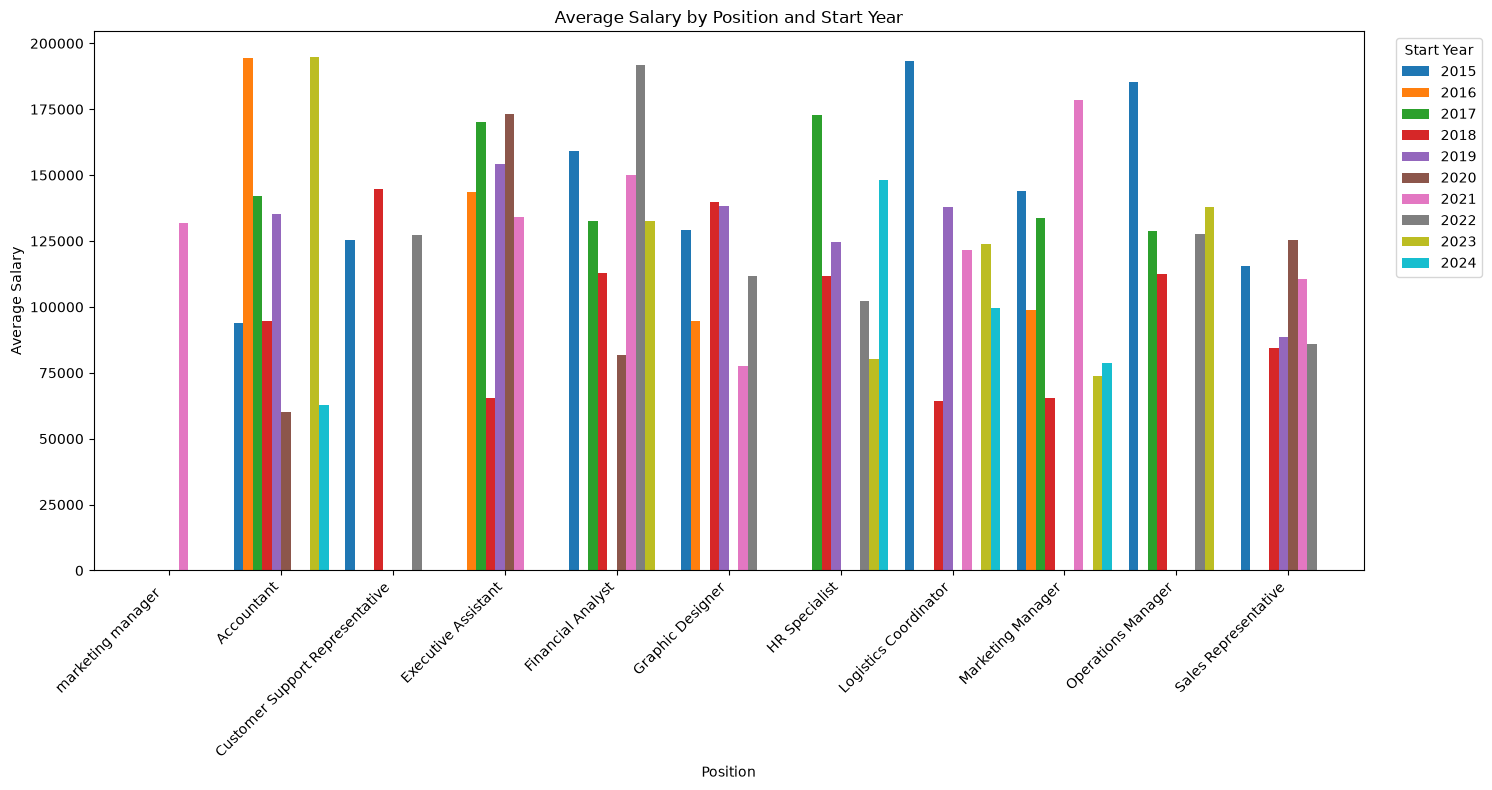

In [24]:
average_salary = (
    df.groupby(['position', 'start_year'], as_index=False)['salary']
    .mean()
    .pivot(index='position', columns='start_year', values='salary')
)

ax = average_salary.plot(kind='bar', figsize=(15, 8), width=0.85)
ax.set_title('Average Salary by Position and Start Year')
ax.set_xlabel('Position')
ax.set_ylabel('Average Salary')
ax.legend(title='Start Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Project Assignments and Distribution Analysis

Each employee is assigned to a project in Neon. The joined project dataset is used to compare salary and years-of-service distributions by project and department.

In [4]:
import random

project_rows = [
    ('Project Atlas', 'Operations'),
    ('Project Beacon', 'Finance'),
    ('Project Cedar', 'Marketing'),
    ('Project Delta', 'Sales'),
    ('Project Ember', 'Human Resources'),
]

with psycopg2.connect(DATABASE_URL) as connection:
    with connection.cursor() as cursor:
        cursor.execute(
            """
            CREATE TABLE IF NOT EXISTS project_assignments (
                assignment_id BIGSERIAL PRIMARY KEY,
                employee_id INTEGER NOT NULL UNIQUE REFERENCES employees(employee_id),
                project_name TEXT NOT NULL,
                project_department TEXT NOT NULL
            )
            """
        )
        cursor.execute('SELECT employee_id FROM employees ORDER BY employee_id')
        employee_ids = [row[0] for row in cursor.fetchall()]
        assignments = [
            (employee_id, *random.choice(project_rows))
            for employee_id in employee_ids
        ]
        cursor.executemany(
            """
            INSERT INTO project_assignments (employee_id, project_name, project_department)
            VALUES (%s, %s, %s)
            ON CONFLICT (employee_id) DO UPDATE SET
                project_name = EXCLUDED.project_name,
                project_department = EXCLUDED.project_department
            """,
            assignments,
        )
        cursor.execute(
            """
            SELECT
                e.employee_id,
                e.name,
                e.salary,
                e.start_date,
                d.department_id,
                d.department,
                pa.project_name,
                pa.project_department
            FROM employees AS e
            INNER JOIN departments AS d
                ON e.department_id = d.department_id
            INNER JOIN project_assignments AS pa
                ON e.employee_id = pa.employee_id
            """
        )
        project_rows_from_db = cursor.fetchall()
        project_columns = [column[0] for column in cursor.description]

project_df = pd.DataFrame(project_rows_from_db, columns=project_columns)
project_df['start_date'] = pd.to_datetime(project_df['start_date'])
project_df['years_of_service'] = (
    (pd.Timestamp.today().normalize() - project_df['start_date']).dt.days / 365.25
).clip(lower=0).round(1)

print('Project assignment rows:', len(project_df))
display(project_df.head())

salary_distribution = project_df.groupby(
    ['project_name', 'department'],
)['salary'].describe().round(2)
years_distribution = project_df.groupby(
    ['project_name', 'department'],
)['years_of_service'].describe().round(2)

print('Salary distribution by project and department:')
display(salary_distribution)
print('Years-of-service distribution by project and department:')
display(years_distribution)

Project assignment rows: 101


,employee_id,name,salary,start_date,department_id,department,project_name,project_department,years_of_service
0,60,Elizabeth Peterson,169868,2019-01-15,1,Finance,Project Ember,Human Resources,7.7
1,68,Amanda Weaver,135953,2019-12-11,10,Administration,Project Cedar,Marketing,6.8
2,76,Tina Tanner,109270,2019-12-07,2,Human Resources,Project Delta,Sales,6.8
3,77,Brian Perry,159882,2015-12-29,5,Finance,Project Ember,Human Resources,10.7
4,80,Craig Maldonado,61523,2021-07-26,2,Human Resources,Project Ember,Human Resources,5.2


Salary distribution by project and department:


count       mean       std       min  \
project_name   department                                                  
Project Atlas  Creative Services      2.0  109953.50  20697.72   95318.0   
               Customer Experience    4.0  109823.25  48891.64   60000.0   
               Finance                2.0  149015.00  33543.73  125296.0   
               Human Resources        1.0  115721.00       NaN  115721.0   
               Marketing              4.0  149274.75  36945.91  112983.0   
               Operations             6.0  119598.83  40547.07   71529.0   
               Sales                  2.0   92887.50   1298.96   91969.0   
Project Beacon Administration         1.0  115992.00       NaN  115992.0   
               Creative Services      4.0  156261.75  22863.48  132574.0   
               Customer Experience    3.0  124877.67  17095.82  110356.0   
               Finance                4.0   86661.25  27729.48   65386.0   
               Marketing              1.0   81883.00       NaN   81883.0   
               Operations             4.0  132690.00  47480.05   88611.0   
               Sales                  1.0  103527.00       NaN  103527.0   
Project Cedar  Administration         1.0  135953.00       NaN  135953.0   
               Customer Experience    6.0  106465.33  60319.08   60000.0   
               Finance                2.0   98994.50   9227.04   92470.0   
               Human Resources        2.0   69948.00   6413.46   65413.0   
               Marketing              1.0  173101.00       NaN  173101.0   
               Operations             3.0  168037.00  48756.38  111760.0   
               Sales                  2.0  125913.00  81822.15   68056.0   
Project Delta  Administration         1.0  110609.00       NaN  110609.0   
               Creative Services      2.0   99969.50   3922.32   97196.0   
               Customer Experience    2.0  168110.00  37196.65  141808.0   
               Finance                4.0  151344.50  37981.45  112423.0   
               Human Resources        2.0  146057.00  52024.67  109270.0   
               Marketing              5.0   96290.80  28950.35   60000.0   
               Operations             3.0  102235.67  16677.73   83055.0   
               Sales                  3.0  122044.00  35483.25   94606.0   
Project Ember  Administration         1.0  166772.00       NaN  166772.0   
               Creative Services      4.0  109590.75  52223.72   66635.0   
               Customer Experience    2.0  132886.50  24675.91  115438.0   
               Finance                7.0  125186.71  48378.73   67138.0   
               Human Resources        3.0   85262.67  42444.10   60000.0   
               Marketing              1.0  132443.00       NaN  132443.0   
               Operations             3.0  110112.67  25397.18   83201.0   
               Sales                  2.0  145343.00  19336.54  131670.0   

                                          25%       50%        75%       max  
project_name   department                                                     
Project Atlas  Creative Services    102635.75  109953.5  117271.25  124589.0  
               Customer Experience   76374.00  104806.5  138255.75  169680.0  
               Finance              137155.50  149015.0  160874.50  172734.0  
               Human Resources      115721.00  115721.0  115721.00  115721.0  
               Marketing            122192.25  145425.5  172508.00  193265.0  
               Operations            87705.75  118453.0  150735.50  170205.0  
               Sales                 92428.25   92887.5   93346.75   93806.0  
Project Beacon Administration       115992.00  115992.0  115992.00  115992.0  
               Creative Services    141754.00  153634.0  168141.75  185205.0  
               Customer Experience  115457.00  120558.0  132138.50  143719.0  
               Finance               71745.25   77002.0   91918.00  127255.0  
               Marketing             81883.0

Years-of-service distribution by project and department:


count   mean   std   min    25%    50%  \
project_name   department                                                    
Project Atlas  Creative Services      2.0   9.10  2.40   7.4   8.25   9.10   
               Customer Experience    4.0   5.48  1.91   3.4   4.38   5.30   
               Finance                2.0   6.95  3.04   4.8   5.88   6.95   
               Human Resources        1.0  10.60   NaN  10.6  10.60  10.60   
               Marketing              4.0   8.75  1.83   6.9   7.50   8.55   
               Operations             6.0   6.42  2.88   2.4   4.28   7.70   
               Sales                  2.0  10.10  1.27   9.2   9.65  10.10   
Project Beacon Administration         1.0   4.30   NaN   4.3   4.30   4.30   
               Creative Services      4.0   9.35  2.82   5.9   7.62   9.90   
               Customer Experience    3.0   9.47  0.31   9.2   9.30   9.40   
               Finance                4.0   4.62  2.27   3.3   3.30   3.60   
               Marketing              1.0   3.90   NaN   3.9   3.90   3.90   
               Operations             4.0   6.20  1.89   4.6   4.68   5.85   
               Sales                  1.0   5.70   NaN   5.7   5.70   5.70   
Project Cedar  Administration         1.0   6.80   NaN   6.8   6.80   6.80   
               Customer Experience    6.0   6.75  3.43   1.8   4.42   7.65   
               Finance                2.0   7.20  5.09   3.6   5.40   7.20   
               Human Resources        2.0   7.40  0.71   6.9   7.15   7.40   
               Marketing              1.0   5.80   NaN   5.8   5.80   5.80   
               Operations             3.0   7.53  4.31   3.1   5.45   7.80   
               Sales                  2.0   2.55  0.21   2.4   2.48   2.55   
Project Delta  Administration         1.0   5.00   NaN   5.0   5.00   5.00   
               Creative Services      2.0   8.45  1.91   7.1   7.78   8.45   
               Customer Experience    2.0   7.70  3.96   4.9   6.30   7.70   
               Finance                4.0   8.07  4.47   2.1   5.93   9.25   
               Human Resources        2.0   6.15  0.92   5.5   5.82   6.15   
               Marketing              5.0   5.34  4.58   1.8   1.80   2.70   
               Operations             3.0   5.50  1.65   4.5   4.55   4.60   
               Sales                  3.0   7.17  2.95   4.2   5.70   7.20   
Project Ember  Administration         1.0   3.40   NaN   3.4   3.40   3.40   
               Creative Services      4.0   4.25  1.42   2.4   3.52   4.50   
               Customer Experience    2.0   7.25  6.29   2.8   5.02   7.25   
               Finance                7.0   7.54  2.87   3.6   5.50   7.70   
               Human Resources        3.0   4.30  2.01   2.0   3.60   5.20   
               Marketing              1.0   9.00   NaN   9.0   9.00   9.00   
               Operations             3.0   7.17  4.37   2.2   5.55   8.90   
               Sales                  2.0   8.30  3.96   5.5   6.90   8.30   

                                      75%   max  
project_name   department                        
Project Atlas  Creative Services     9.95  10.8  
               Customer Experience   6.40   7.9  
               Finance               8.02   9.1  
               Human Resources      10.60  10.6  
               Marketing             9.80  11.0  
               Operations            8.05   9.4  
               Sales                10.55  11.0  
Project Beacon Administration        4.30   4.3  
               Creative Services    11.62  11.7  
               Customer Experience   9.60   9.8  
               Finance               4.92   8.0  
               Marketing             3.90   3.9  
               Operations            7.38   8.5  
               Sales                 5.70   5.7  
Project Cedar  Administration        6.80   6.8  
               Customer Experience   8.85  10.8  
               Finance               9.00  10.8  
               Human Resources       7.65  

## Section 1: Department Salary Heatmap

This heatmap shows the average salary for each department across start years 2019 through 2024. Darker cells represent higher average salaries.

### Main Findings in the Graph:

- Highest Peak Salaries: Marketing reached the top single-cohort average ($173,101 in 2020), followed by Administration ($166,772 in 2023) and Finance ($165,228 in 2019).   
- Lowest Pay Averages: The lowest starting averages were recorded in Human Resources ($60,000 in 2024), Customer Experience ($65,226 in 2024), and Creative Services ($66,635 in 2022).   
- Hiring Gaps: Blank white cells highlight years with no hires in specific departments (e.g., Marketing in 2021; Administration in 2020 & 2024).   
- Pay Trend over Time: Earlier hire cohorts (2019–2021) generally average higher salaries compared to 2024 hires.  

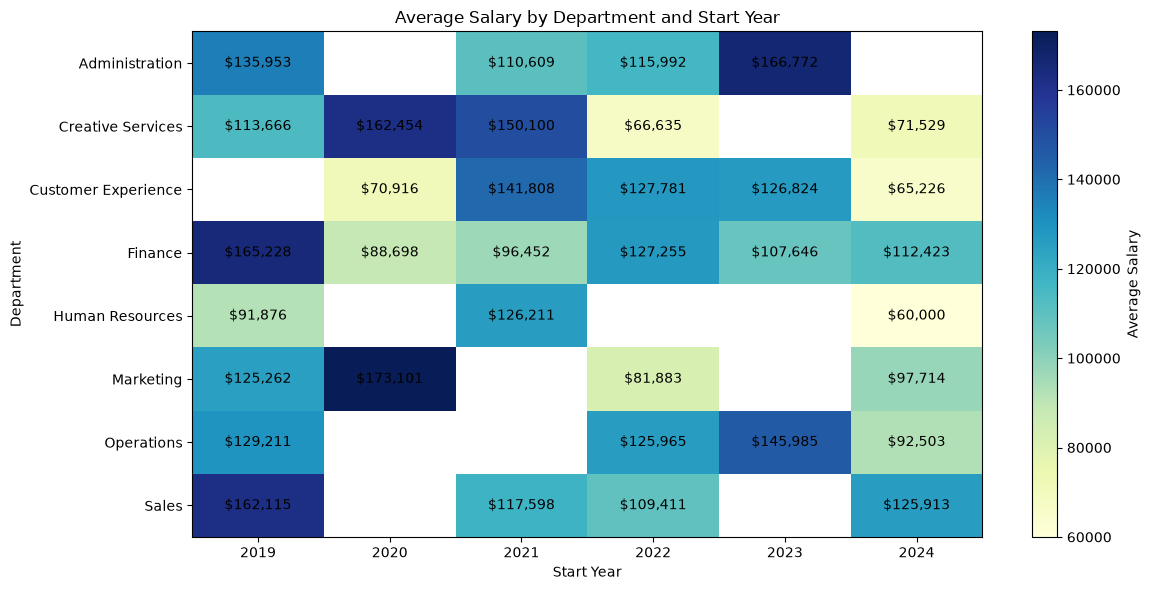

In [5]:
import matplotlib.pyplot as plt
import numpy as np

analysis_df = project_df.copy()
analysis_df['start_year'] = analysis_df['start_date'].dt.year
analysis_df = analysis_df[analysis_df['start_year'].between(2019, 2024)]

salary_heatmap = analysis_df.pivot_table(
    index='department',
    columns='start_year',
    values='salary',
    aggfunc='mean',
)

fig, ax = plt.subplots(figsize=(12, 6))
image = ax.imshow(salary_heatmap, aspect='auto', cmap='YlGnBu')
ax.set_title('Average Salary by Department and Start Year')
ax.set_xlabel('Start Year')
ax.set_ylabel('Department')
ax.set_xticks(range(len(salary_heatmap.columns)), salary_heatmap.columns)
ax.set_yticks(range(len(salary_heatmap.index)), salary_heatmap.index)
for row_index in range(salary_heatmap.shape[0]):
    for column_index in range(salary_heatmap.shape[1]):
        value = salary_heatmap.iloc[row_index, column_index]
        if not np.isnan(value):
            ax.text(column_index, row_index, f'${value:,.0f}', ha='center', va='center')
fig.colorbar(image, ax=ax, label='Average Salary')
fig.tight_layout()
plt.show()

## Average Salary by Department

Each point represents one department's average salary and average years of service for employees who started between 2019 and 2024.

### Main Findings in the Graph:

- Top Earning Departments: Administration ranks highest in average salary (> $130,000), followed by Sales (~$126,400) and Operations (~$124,400).   
- Key Departmental Outliers:
    - Human Resources Highest average work time (~5.35 years) but lowest average salary (~$103,700).   
    - Creative Services: High average work time (~5.35 years) with mid-tier pay (~$118,300).   
    - Marketing: Lowest average work time (~3.82 years) with a mid-range average salary (~$112,200).   

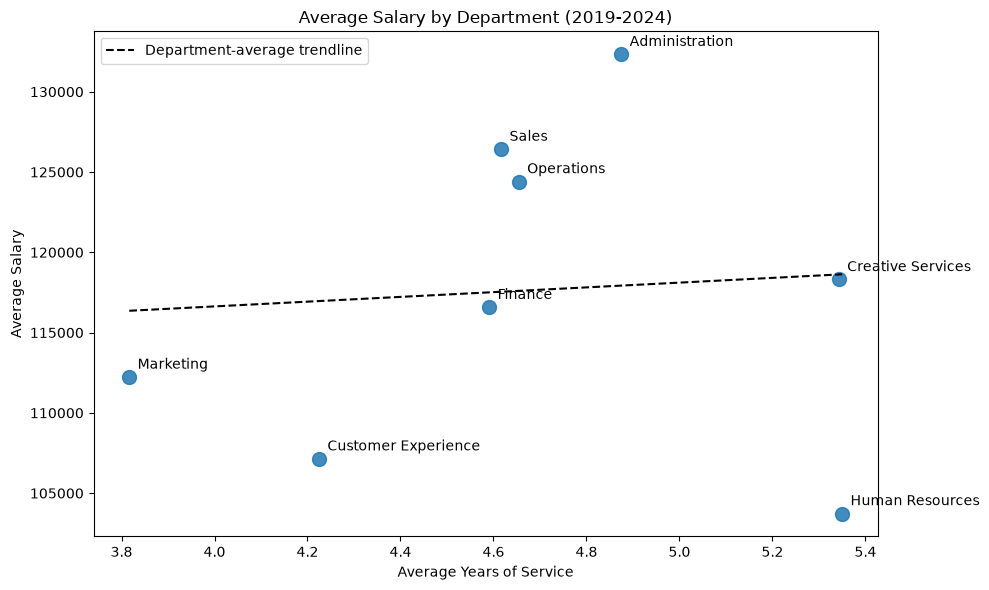

In [9]:
department_salary_summary = (
    analysis_df.groupby('department', as_index=False)
    .agg(
        mean_salary=('salary', 'mean'),
        mean_years_of_service=('years_of_service', 'mean'),
    )
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    department_salary_summary['mean_years_of_service'],
    department_salary_summary['mean_salary'],
    s=100,
    alpha=0.85,
)

for _, department_row in department_salary_summary.iterrows():
    ax.annotate(
        department_row['department'],
        (
            department_row['mean_years_of_service'],
            department_row['mean_salary'],
        ),
        xytext=(6, 6),
        textcoords='offset points',
    )

trend_x = department_salary_summary['mean_years_of_service'].to_numpy()
trend_y = department_salary_summary['mean_salary'].to_numpy()
trend_slope, trend_intercept = np.polyfit(trend_x, trend_y, 1)
line_x = np.linspace(trend_x.min(), trend_x.max(), 100)
ax.plot(
    line_x,
    trend_slope * line_x + trend_intercept,
    color='black',
    linestyle='--',
    label='Department-average trendline',
)
ax.set_title('Average Salary by Department (2019-2024)')
ax.set_xlabel('Average Years of Service')
ax.set_ylabel('Average Salary')
ax.legend()
fig.tight_layout()
plt.show()

## Section 3: Department Employee Service Trends

This line chart shows the average years of service for employees in each department by their start year, using the 2019-2024 analysis range.

### Main Findings in the Graph:

- Down-salary Trend Across All Departments: 
    - Average years of service downgraded similar linearly for every department as the start year advances from 2019 (~6.8–7.5 years) down to 2024 (~1.8–2.6 years).   
    - Highest work time Cohort (2019): Finance recorded the highest average work time in the 2019 cohort (~7.4 years), closely followed by Operations (~7.3 years).   
    - Lowest Tenure Cohort (2024): Customer Experience dropped to the lowest average work time among 2024 hires (~1.8 years), while Sales retained the highest relative work time in that same cohort (~2.6 years).   
    - Consistent Progression: Department lines track closely together throughout the timeline, reflecting a standard mathematical reduction in work time inherent to more recent start dates.   

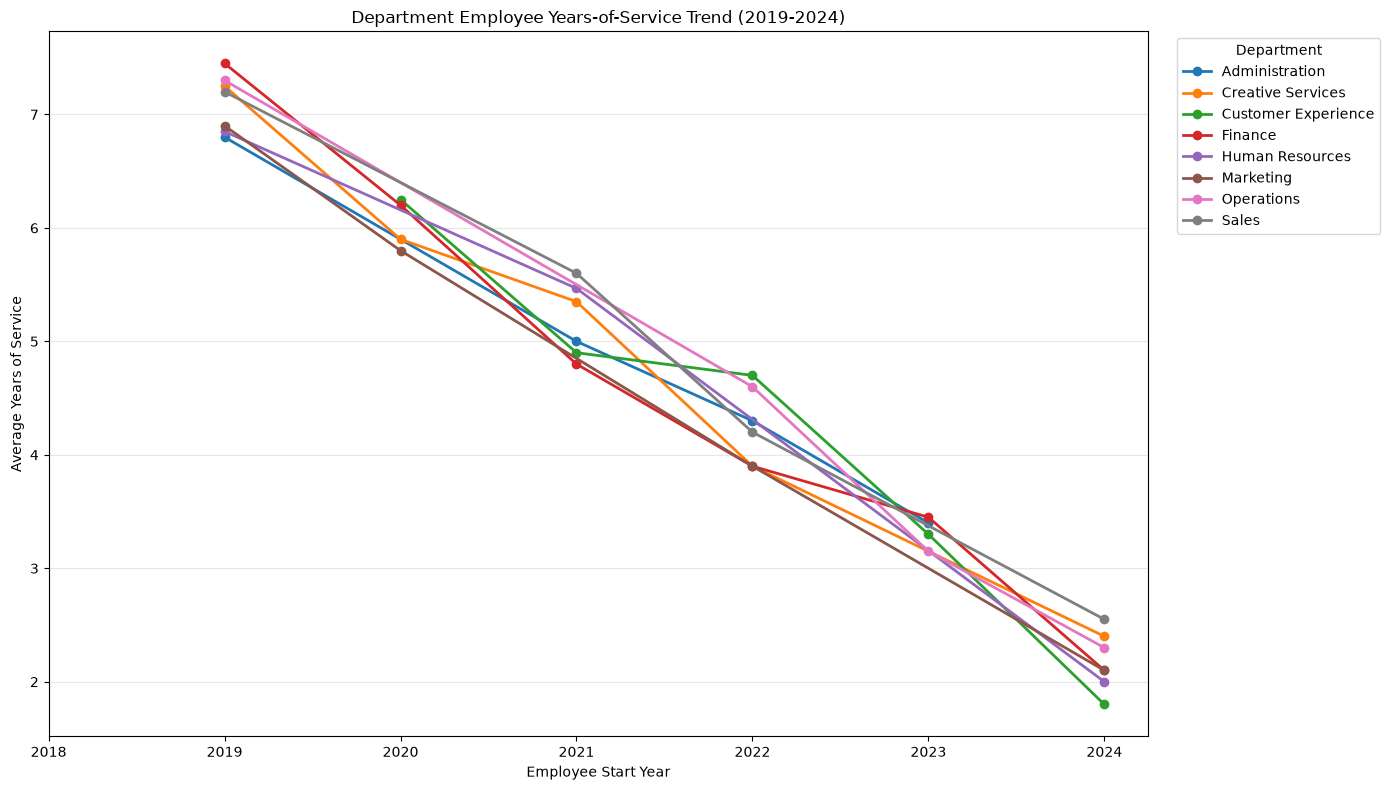

In [12]:
yearly_department_service = (
    analysis_df.groupby(['department', 'start_year'], as_index=False)['years_of_service']
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 8))
for department, department_data in yearly_department_service.groupby('department'):
    ax.plot(
        department_data['start_year'],
        department_data['years_of_service'],
        marker='o',
        linewidth=2,
        label=department,
    )

ax.set_title('Department Employee Years-of-Service Trend (2019-2024)')
ax.set_xlabel('Employee Start Year')
ax.set_ylabel('Average Years of Service')
ax.set_xticks(range(2018, 2025))
ax.legend(title='Department', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()